# BioPlex Ground Truth Collection
Build a **co-complex (AP-MS)** physical-interaction ground truth from **BioPlex 3.0** for the protein embedding benchmark.

BioPlex (Huttlin et al.) is a systematic **affinity purification–mass spectrometry (AP-MS)** interactome. It is the methodological complement to HuRI's yeast two-hybrid map: Y2H detects direct binary contacts, AP-MS detects co-complex association. Together they cover the two major orthogonal experimental approaches to the human interactome.

**Source dataset:** `BioPlex_293T_Network_10K_Dec_2019.tsv` (BioPlex 3.0, HEK293T network) from https://bioplex.hms.harvard.edu — 118,162 high-confidence interactions (pInt ≥ 0.75), already carrying `UniprotA`/`UniprotB` columns.

**Choices for this build:**
- **All edges** in the published high-confidence network are positives (no extra pInt filter).
- Rows with an `UNKNOWN` UniProt mapping are dropped.
- UniProt accessions are **canonicalised** (isoform suffix `-2` stripped) to match the canonical-only protein universe.
- AP-MS edges are undirected; pairs are stored symmetrically.
- Negatives = pairs where both proteins are in the BioPlex network but no edge was reported.

Same matrix structure as the other notebooks: `1` positive, `0` negative, `NaN` = at least one protein outside the BioPlex network. Proteins are ordered using the **shared** `ground_truth_proteins.tsv` index so this matrix aligns row-for-row with the others.

In [1]:
import ssl
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

## 0. Locate the shared ground-truth folder

The canonical protein universe lives in `protgpt/ppi_ground_truth/ground_truth_proteins.tsv` (20,431 alphabetically-sorted UniProt accessions). All shipped matrices are `(20431, 20431)`, so we key off this file to guarantee alignment.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'protgpt' / 'ppi_ground_truth').is_dir():
            return p
    raise FileNotFoundError('could not locate protgpt/ppi_ground_truth from ' + str(start))

REPO = find_repo_root(Path.cwd())
GT_DIR = REPO / 'protgpt' / 'ppi_ground_truth'
PROT_TSV = GT_DIR / 'ground_truth_proteins.tsv'
DATA_DIR = Path.cwd() / '_bioplex_data'
DATA_DIR.mkdir(exist_ok=True)
print('repo root :', REPO)
print('gt dir    :', GT_DIR)
print('data dir  :', DATA_DIR)

repo root : C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt
gt dir    : C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt\protgpt\ppi_ground_truth
data dir  : C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\protgpt\experiments\exp2\ground_truth_notebooks\_bioplex_data


# 1. Download the BioPlex 3.0 (293T) network

The network table has `GeneA/GeneB` (Entrez), `UniprotA/UniprotB`, `SymbolA/SymbolB`, and the AP-MS probabilities `pW`, `pNI`, `pInt`. The file is already the high-confidence network (pInt ≥ 0.75).

In [3]:
BIOPLEX_URL = 'https://bioplex.hms.harvard.edu/data/BioPlex_293T_Network_10K_Dec_2019.tsv'
bp_path = DATA_DIR / 'BioPlex_293T.tsv'

if not bp_path.exists():
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    print('Downloading BioPlex 3.0 293T network ...')
    with urllib.request.urlopen(BIOPLEX_URL, context=ctx) as r, open(bp_path, 'wb') as f:
        f.write(r.read())

df_bp = pd.read_csv(bp_path, sep='\t')
print(f"BioPlex interactions: {len(df_bp):,}")
print(f"Columns: {list(df_bp.columns)}")
print(f"pInt range: [{df_bp['pInt'].min():.3f}, {df_bp['pInt'].max():.3f}]")
df_bp[['UniprotA', 'UniprotB', 'SymbolA', 'SymbolB', 'pInt']].head()

BioPlex interactions: 118,162
Columns: ['GeneA', 'GeneB', 'UniprotA', 'UniprotB', 'SymbolA', 'SymbolB', 'pW', 'pNI', 'pInt']
pInt range: [0.750, 1.000]


,UniprotA,UniprotB,SymbolA,SymbolB,pInt
0,P00813,A5A3E0,ADA,POTEF,0.999882
1,Q8N7W2-2,P26373,BEND7,RPL13,0.774336
2,Q8N7W2-2,Q09028-3,BEND7,RBBP4,0.999936
3,Q8N7W2-2,Q9Y3U8,BEND7,RPL36,0.871817
4,Q8N7W2-2,P36578,BEND7,RPL4,0.799362


# 2. Build undirected UniProt interaction pairs

Drop rows with an `UNKNOWN` accession, canonicalise UniProt IDs (strip isoform suffix), and emit an undirected pair `(min, max)` per edge. Self-pairs are dropped.

In [4]:
def canon(acc: str) -> str:
    """Strip UniProt isoform suffix: Q8N7W2-2 -> Q8N7W2."""
    return str(acc).split('-')[0]

positive_pairs = set()
bioplex_nodes = set()
n_unknown = 0

for a, b in zip(df_bp['UniprotA'], df_bp['UniprotB']):
    if str(a) == 'UNKNOWN' or str(b) == 'UNKNOWN':
        n_unknown += 1
        continue
    a, b = canon(a), canon(b)
    bioplex_nodes.add(a)
    bioplex_nodes.add(b)
    if a != b:
        positive_pairs.add(tuple(sorted((a, b))))

print(f"Rows dropped (UNKNOWN mapping): {n_unknown:,}")
print(f"BioPlex proteins (nodes):       {len(bioplex_nodes):,}")
print(f"Undirected positive pairs:      {len(positive_pairs):,}")

Rows dropped (UNKNOWN mapping): 4,950


BioPlex proteins (nodes):       13,667
Undirected positive pairs:      113,212


# 3. Load the canonical protein universe

Proteins ordered alphabetically — identical order and content to the other ground-truth matrices.

In [5]:
prot_df = pd.read_csv(PROT_TSV, sep='\t')
all_proteins_sorted = prot_df['protein'].tolist()
n = len(all_proteins_sorted)
prot_to_idx = {p: i for i, p in enumerate(all_proteins_sorted)}
assert all_proteins_sorted == sorted(all_proteins_sorted), 'universe must be alphabetical'
print(f"Total proteins: {n}")
print(f"Matrix shape: {n} x {n}")

Total proteins: 20431
Matrix shape: 20431 x 20431


In [6]:
universe = set(all_proteins_sorted)
in_both = bioplex_nodes & universe
bp_only = bioplex_nodes - universe

print(f"BioPlex proteins:                  {len(bioplex_nodes):,}")
print(f"In both BioPlex and universe:      {len(in_both):,}")
print(f"In BioPlex only (not in universe): {len(bp_only):,}")
if bp_only:
    print(f"\nSample BioPlex-only IDs: {sorted(bp_only)[:10]}")

BioPlex proteins:                  13,667
In both BioPlex and universe:      13,341
In BioPlex only (not in universe): 326

Sample BioPlex-only IDs: ['A0JLV8', 'A1A4T8', 'A2A457', 'A2AAZ0', 'A2BFH1', 'A2BHY4', 'A2NHM0', 'A2RRD2', 'A2RRF1', 'A2RUP7']


# 4. Build the ground truth matrix

- `1` = positive (BioPlex AP-MS edge, both proteins in the universe)
- `0` = negative (both proteins in the BioPlex network, no reported edge)
- `NaN` = at least one protein not in the BioPlex network

"In the network" = the protein appears in at least one high-confidence BioPlex interaction.

In [7]:
# Initialize all NaN
bioplex_matrix = np.full((n, n), np.nan, dtype=np.float32)

# Filter BioPlex nodes to the universe; set all BioPlex×BioPlex pairs to 0 (negative by default)
bp_in_universe = sorted(p for p in bioplex_nodes if p in prot_to_idx)
bp_indices = np.array([prot_to_idx[p] for p in bp_in_universe])

bioplex_matrix[np.ix_(bp_indices, bp_indices)] = 0.0
print(f"BioPlex proteins in universe: {len(bp_indices)} / {n}")
print(f"Set {len(bp_indices)}x{len(bp_indices)} BioPlex submatrix to 0 (negative)")

BioPlex proteins in universe: 13341 / 20431
Set 13341x13341 BioPlex submatrix to 0 (negative)


In [8]:
# Set positives from the BioPlex pairs
n_set = 0
n_skipped = 0
for p1, p2 in positive_pairs:
    if p1 in prot_to_idx and p2 in prot_to_idx:
        i, j = prot_to_idx[p1], prot_to_idx[p2]
        bioplex_matrix[i, j] = 1.0
        bioplex_matrix[j, i] = 1.0
        n_set += 1
    else:
        n_skipped += 1

print(f"Set {n_set:,} positive pairs (both directions)")
print(f"Skipped {n_skipped:,} pairs (protein not in universe)")

Set 108,968 positive pairs (both directions)
Skipped 4,244 pairs (protein not in universe)


In [9]:
# Set diagonal to NaN
np.fill_diagonal(bioplex_matrix, np.nan)

# Verify counts
upper = bioplex_matrix[np.triu_indices(n, k=1)]
n_pos = np.nansum(upper == 1)
n_neg = np.nansum(upper == 0)
n_nan = np.sum(np.isnan(upper))

print(f"Upper triangle counts:")
print(f"  Positive (1): {int(n_pos):>12,}")
print(f"  Negative (0): {int(n_neg):>12,}")
print(f"  NaN:          {int(n_nan):>12,}")
print(f"  Total:        {len(upper):>12,}")
print(f"\n  Pos/Neg ratio: {n_pos/n_neg:.6f}")
print(f"  Matrix is symmetric: {np.allclose(bioplex_matrix, bioplex_matrix.T, equal_nan=True)}")

Upper triangle counts:
  Positive (1):      108,968
  Negative (0):   88,875,502
  NaN:           119,718,195
  Total:         208,702,665

  Pos/Neg ratio: 0.001226


  Matrix is symmetric: True


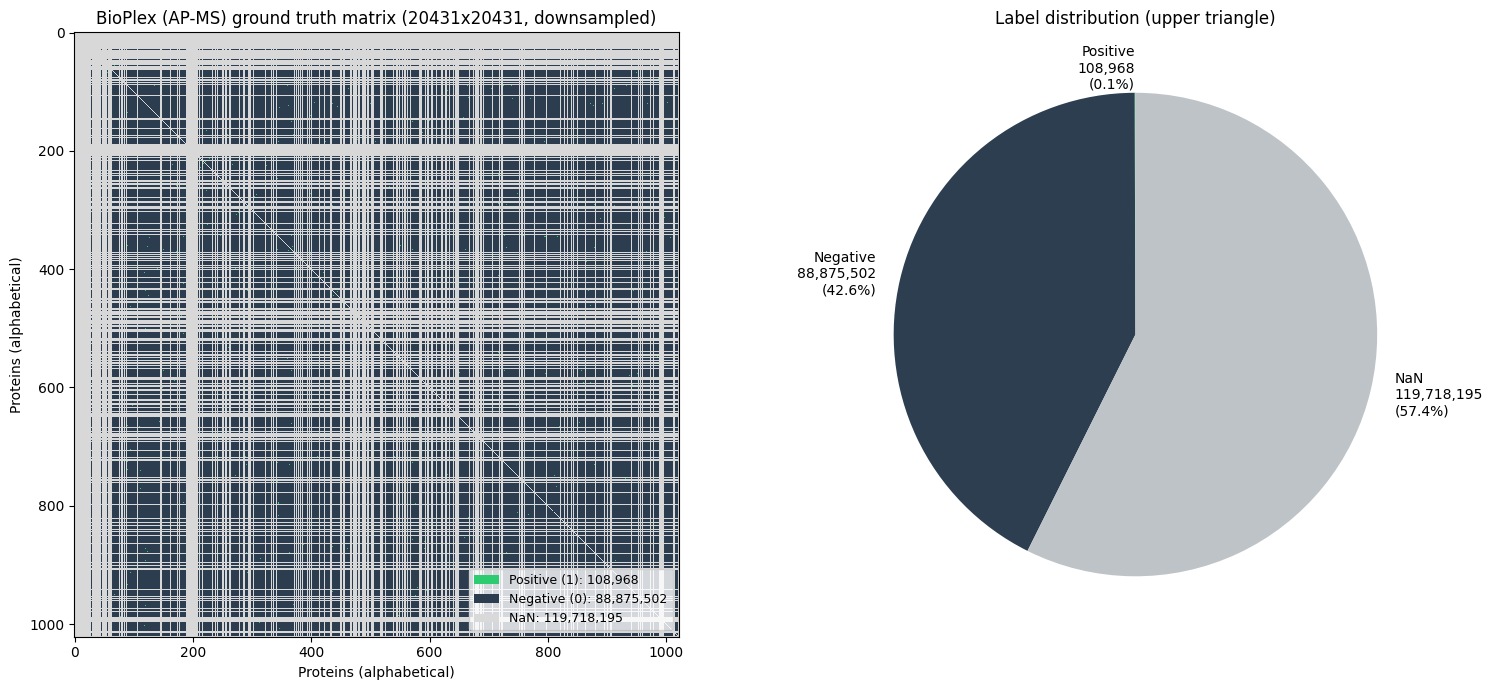

In [10]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

step = max(1, n // 1000)
display_matrix = bioplex_matrix[::step, ::step]

rgb = np.zeros((*display_matrix.shape, 3), dtype=np.float32)
nan_mask = np.isnan(display_matrix)
neg_mask = display_matrix == 0
pos_mask = display_matrix == 1

rgb[nan_mask] = [0.85, 0.85, 0.85]
rgb[neg_mask] = [0.17, 0.24, 0.31]
rgb[pos_mask] = [0.18, 0.80, 0.44]

axes[0].imshow(rgb, aspect='equal', interpolation='nearest')
axes[0].set_title(f"BioPlex (AP-MS) ground truth matrix ({n}x{n}, downsampled)", fontsize=12)
axes[0].set_xlabel("Proteins (alphabetical)")
axes[0].set_ylabel("Proteins (alphabetical)")

legend_elements = [
    Patch(facecolor=[0.18, 0.80, 0.44], label=f'Positive (1): {int(n_pos):,}'),
    Patch(facecolor=[0.17, 0.24, 0.31], label=f'Negative (0): {int(n_neg):,}'),
    Patch(facecolor=[0.85, 0.85, 0.85], label=f'NaN: {int(n_nan):,}'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

sizes_plot = [int(n_pos), int(n_neg), int(n_nan)]
labels = [f'Positive\n{int(n_pos):,}\n({n_pos/len(upper)*100:.1f}%)',
          f'Negative\n{int(n_neg):,}\n({n_neg/len(upper)*100:.1f}%)',
          f'NaN\n{int(n_nan):,}\n({n_nan/len(upper)*100:.1f}%)']
colors = ['#2ecc71', '#2c3e50', '#bdc3c7']

axes[1].pie(sizes_plot, labels=labels, colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Label distribution (upper triangle)', fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth

# save_ppi_ground_truth stores only the positives and the covered-protein
# universe (~36x smaller, reconstructs the dense matrix exactly) and will
# not replace an existing file: published results are pinned to the
# matrices in reference/, and these source databases change over time.
# save
out_npz = GT_DIR / 'bioplex_ground_truth_matrix.npz'

save_ppi_ground_truth(Path(GT_DIR_DEFAULT) / "bioplex_ground_truth_matrix.npz", bioplex_matrix)

npz_size = out_npz.stat().st_size / 1e6
print(f"Saved {out_npz.name} ({npz_size:.1f} MB)")
print(f"\nParameters used:")
print(f"  Source: BioPlex 3.0 (HEK293T network, 10K, Dec 2019)")
print(f"  Assay: affinity purification-mass spec (AP-MS), co-complex")
print(f"  Confidence filter: none beyond published network (pInt >= 0.75)")
print(f"  ID handling: UniProt columns, isoform suffix stripped, UNKNOWN dropped")
print(f"\nTo load later:")
print(f"  matrix = np.load('bioplex_ground_truth_matrix.npz')['matrix']")
print(f"  # shape ({n}, {n}), values: 0, 1, NaN")

Saved bioplex_ground_truth_matrix.npz (60.7 MB)
Saved bioplex_ground_truth_proteins.tsv

Parameters used:
  Source: BioPlex 3.0 (HEK293T network, 10K, Dec 2019)
  Assay: affinity purification-mass spec (AP-MS), co-complex
  Confidence filter: none beyond published network (pInt >= 0.75)
  ID handling: UniProt columns, isoform suffix stripped, UNKNOWN dropped

To load later:
  matrix = np.load('bioplex_ground_truth_matrix.npz')['matrix']
  # shape (20431, 20431), values: 0, 1, NaN
